# Three-level DRAG echo-root-Lorentzian spectroscopy to 80 MHz

This notebook compares the ordinary echo-root-Lorentzian pulse with a **DRAG plus quadratic-Stark-compensated echo-root-Lorentzian** pulse in a three-level Lindblad model. The scan spans peak Rabi frequencies from 0 to 80 MHz and produces two-dimensional detuning-amplitude maps for all three populations. The midpoint echo is enabled (`ECHO = True`).

The DRAG convention is

$$\Omega_Q(t)=-\beta\,\frac{d\Omega_I(t)/dt}{\alpha}.$$

The derivative acts on the smooth Lorentzian envelope. With `ECHO = True`, the same $0/\pi$ phase is applied to both $I$ and $Q$ without differentiating the ideal instantaneous phase jump.

In [1]:
from pathlib import Path
import os
import sys
import time

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from echospec.figures import FigureVariant, apply_figure_style, save_figure
from echospec.simulation.qutrit import simulate_qutrit_map

apply_figure_style(FigureVariant.PAPER)

DURATION_US = 10.0
CUTOFF = 0.002
ORDER = 0.5
ANHARMONICITY_MHZ = -200.0
T1_US = 51.24
T_PHI_US = 7.87
DRAG_BETA = 2.0
ECHO = True
RABI_MHZ = np.linspace(0.0, 80.0, 41)
DETUNING_MHZ = np.linspace(-1.0, 1.0, 201)
STEPS_PER_HALF = 5000

print(f'Grid: {RABI_MHZ.size} amplitudes x {DETUNING_MHZ.size} detunings')
print(f'Pulse: L={DURATION_US:g} us, c={CUTOFF:g}, beta={DRAG_BETA:g}, echo={ECHO}')

Grid: 41 amplitudes x 201 detunings
Pulse: L=10 us, c=0.002, beta=2, echo=True


## Define and inspect the DRAG echo-root-Lorentzian pulse

The function below returns normalized $I/\Omega_0$ and $Q/\Omega_0$. The simulator uses the complex rotating-wave coupling $\Omega_I-i\Omega_Q$.

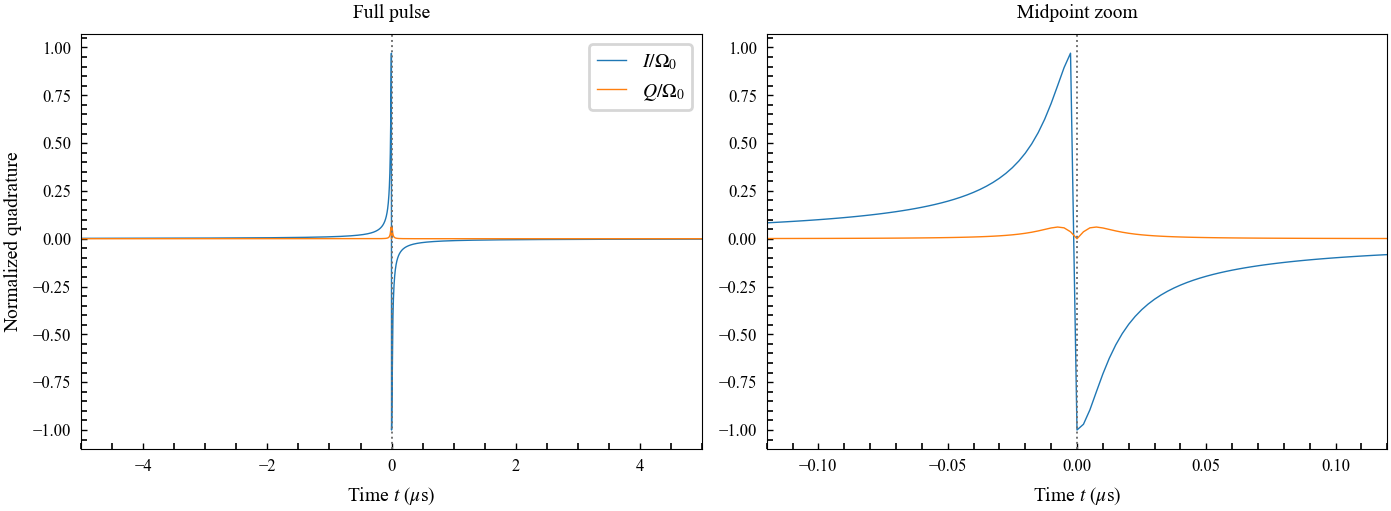

max |Q| / max |I| = 0.06112


In [2]:
def drag_echo_lorentzian_envelope(
    time_us, *, duration_us, cutoff, order, anharmonicity_mhz, beta, echo
):
    time_us = np.asarray(time_us, dtype=float)
    sigma_us = (duration_us / 2) / np.sqrt(cutoff ** (-1 / order) - 1)
    scaled = time_us / sigma_us
    base = (1 + scaled**2) ** (-order)
    base_derivative = (
        -2 * order * time_us / sigma_us**2
        * (1 + scaled**2) ** (-order - 1)
    )
    alpha_angular_per_us = 2 * np.pi * anharmonicity_mhz
    q_base = -beta * base_derivative / alpha_angular_per_us
    phase_sign = np.where(time_us < 0, 1.0, -1.0) if echo else 1.0
    return phase_sign * base, phase_sign * q_base

time_us = np.linspace(-DURATION_US / 2, DURATION_US / 2, 4001)
i_norm, q_norm = drag_echo_lorentzian_envelope(
    time_us, duration_us=DURATION_US, cutoff=CUTOFF, order=ORDER,
    anharmonicity_mhz=ANHARMONICITY_MHZ, beta=DRAG_BETA, echo=ECHO,
)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), constrained_layout=True)
for ax, limits, title in zip(
    axes, [(-DURATION_US / 2, DURATION_US / 2), (-0.12, 0.12)],
    ['Full pulse', 'Midpoint zoom'],
):
    ax.plot(time_us, i_norm, label=r'$I/\Omega_0$')
    ax.plot(time_us, q_norm, label=r'$Q/\Omega_0$')
    ax.axvline(0, color='0.45', lw=0.7, ls=':')
    ax.set_xlim(*limits)
    ax.set_xlabel(r'Time $t$ ($\mu$s)')
    ax.set_title(title)
axes[0].set_ylabel('Normalized quadrature')
axes[0].legend(fontsize=7)
plt.show()
print(f'max |Q| / max |I| = {np.max(np.abs(q_norm)):.5f}')

## Optimize quadratic Stark compensation

We add $\Delta_{\rm corr}(t)/2\pi=\kappa[\Omega_I(t)/2\pi]^2$ and choose $\kappa$ by minimizing the RMS fitted central-minimum displacement from the bare transition. A compact grid is used for coarse-to-fine optimization; the selected value is then evaluated on the full map.

Selected kappa = +0.001750 1/MHz
center RMS from zero = 3.54 kHz
center RMS about mean = 3.54 kHz
max |center| = 6.60 kHz
optimization-grid max leakage = 0.16125


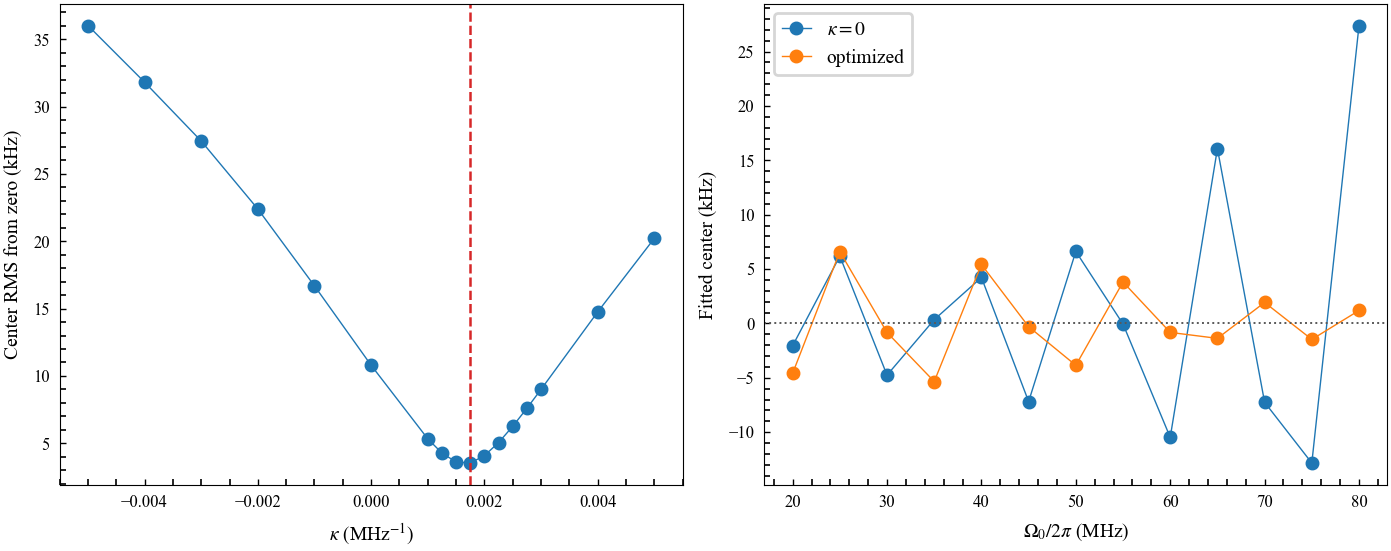

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/15_stark_kappa_optimization_80mhz.pdf
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/15_stark_kappa_optimization_80mhz.png
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/15_stark_kappa_optimization_80mhz.svg


In [3]:
OPT_RABI_MHZ = np.linspace(20.0, 80.0, 13)
OPT_DETUNING_MHZ = np.linspace(-1.0, 1.0, 101)
OPT_STEPS_PER_HALF = 2500
FIT_WINDOW_MHZ = 0.35

def fitted_central_minima(detuning_mhz, excited_population):
    mask = np.abs(detuning_mhz) <= FIT_WINDOW_MHZ
    x = detuning_mhz[mask]
    centers = []
    for row in excited_population[:, mask]:
        index = int(np.argmin(row))
        center = x[index]
        if 0 < index < x.size - 1:
            coefficients = np.polyfit(x[index - 1:index + 2], row[index - 1:index + 2], 2)
            if coefficients[0] > 0:
                candidate = -coefficients[1] / (2 * coefficients[0])
                if x[index - 1] <= candidate <= x[index + 1]:
                    center = candidate
        centers.append(center)
    return np.asarray(centers)

OPT_COMMON = dict(
    duration_us=DURATION_US, detuning_mhz=OPT_DETUNING_MHZ,
    rabi_mhz=OPT_RABI_MHZ, t1_us=T1_US, t_phi_us=T_PHI_US,
    anharmonicity_mhz=ANHARMONICITY_MHZ,
    num_steps_per_half=OPT_STEPS_PER_HALF, cutoff=CUTOFF,
    echo=ECHO, order=ORDER, drag_beta=DRAG_BETA,
)

optimization = {}
def evaluate_kappa(kappa):
    key = float(np.round(kappa, 8))
    if key not in optimization:
        result = simulate_qutrit_map(**OPT_COMMON, stark_kappa_mhz_inv=key)
        centers = fitted_central_minima(OPT_DETUNING_MHZ, result.excited)
        optimization[key] = dict(
            centers=centers,
            rms_zero=float(np.sqrt(np.mean(centers**2))),
            rms_centered=float(np.std(centers)),
            max_abs=float(np.max(np.abs(centers))),
            max_leakage=float(np.max(result.second_excited)),
        )
    return optimization[key]

coarse_kappas = np.linspace(-0.005, 0.005, 11)
for kappa in coarse_kappas:
    evaluate_kappa(kappa)
coarse_best = min(coarse_kappas, key=lambda value: evaluate_kappa(value)['rms_zero'])
fine_kappas = np.linspace(coarse_best - 0.001, coarse_best + 0.001, 9)
for kappa in fine_kappas:
    evaluate_kappa(kappa)
STARK_KAPPA = min(optimization, key=lambda value: optimization[value]['rms_zero'])
best = optimization[STARK_KAPPA]
print(f'Selected kappa = {STARK_KAPPA:+.6f} 1/MHz')
print(f"center RMS from zero = {1e3 * best['rms_zero']:.2f} kHz")
print(f"center RMS about mean = {1e3 * best['rms_centered']:.2f} kHz")
print(f"max |center| = {1e3 * best['max_abs']:.2f} kHz")
print(f"optimization-grid max leakage = {best['max_leakage']:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), constrained_layout=True)
ordered = np.asarray(sorted(optimization))
axes[0].plot(ordered, [1e3 * optimization[k]['rms_zero'] for k in ordered], 'o-')
axes[0].axvline(STARK_KAPPA, color='C3', ls='--', lw=0.9)
axes[0].set(xlabel=r'$\kappa$ (MHz$^{-1}$)', ylabel='Center RMS from zero (kHz)')
for kappa, label in [(0.0, r'$\kappa=0$'), (STARK_KAPPA, 'optimized')]:
    axes[1].plot(OPT_RABI_MHZ, 1e3 * evaluate_kappa(kappa)['centers'], 'o-', label=label)
axes[1].axhline(0, color='0.35', lw=0.7, ls=':')
axes[1].set(xlabel=r'$\Omega_0/2\pi$ (MHz)', ylabel='Fitted center (kHz)')
axes[1].legend(fontsize=7)
saved = save_figure(
    fig, '15_stark_kappa_optimization_80mhz',
    variant=FigureVariant.PAPER, formats=('pdf', 'png', 'svg'), dpi=300,
)
plt.show()
print(*saved, sep='\n')

## Run the dense three-level maps

Both protocols use identical detuning, peak-Rabi, decoherence, cutoff, and integration grids. The second row adds the derivative quadrature and the optimized quadratic Stark correction.

In [4]:
COMMON = dict(
    duration_us=DURATION_US,
    detuning_mhz=DETUNING_MHZ,
    rabi_mhz=RABI_MHZ,
    t1_us=T1_US,
    t_phi_us=T_PHI_US,
    anharmonicity_mhz=ANHARMONICITY_MHZ,
    num_steps_per_half=STEPS_PER_HALF,
    cutoff=CUTOFF,
    echo=ECHO,
    order=ORDER,
)

PLAIN_NAME = 'Echo-root-Lorentzian' if ECHO else 'Root-Lorentzian'
DRAG_NAME = 'DRAG + Stark echo-root-Lorentzian' if ECHO else 'DRAG + Stark root-Lorentzian'
results = {}
protocols = [(PLAIN_NAME, 0.0, 0.0), (DRAG_NAME, DRAG_BETA, STARK_KAPPA)]
for name, beta, kappa in protocols:
    started = time.perf_counter()
    results[name] = simulate_qutrit_map(
        **COMMON, drag_beta=beta, stark_kappa_mhz_inv=kappa
    )
    elapsed = time.perf_counter() - started
    print(f'{name}: {elapsed:.1f} s')

Echo-root-Lorentzian: 26.0 s
DRAG + Stark echo-root-Lorentzian: 26.0 s


In [5]:
for name, result in results.items():
    total = result.ground + result.excited + result.second_excited
    np.testing.assert_allclose(total, 1.0, atol=2e-6)
    for population in (result.ground, result.excited, result.second_excited):
        assert np.all(np.isfinite(population))
        assert population.min() >= 0 and population.max() <= 1
print('Population normalization and physical-range checks passed.')

Population normalization and physical-range checks passed.


## All three populations

Rows compare the ordinary and DRAG pulses. Columns show $P_g$, $P_e$, and leakage population $P_f$ on matched color scales.

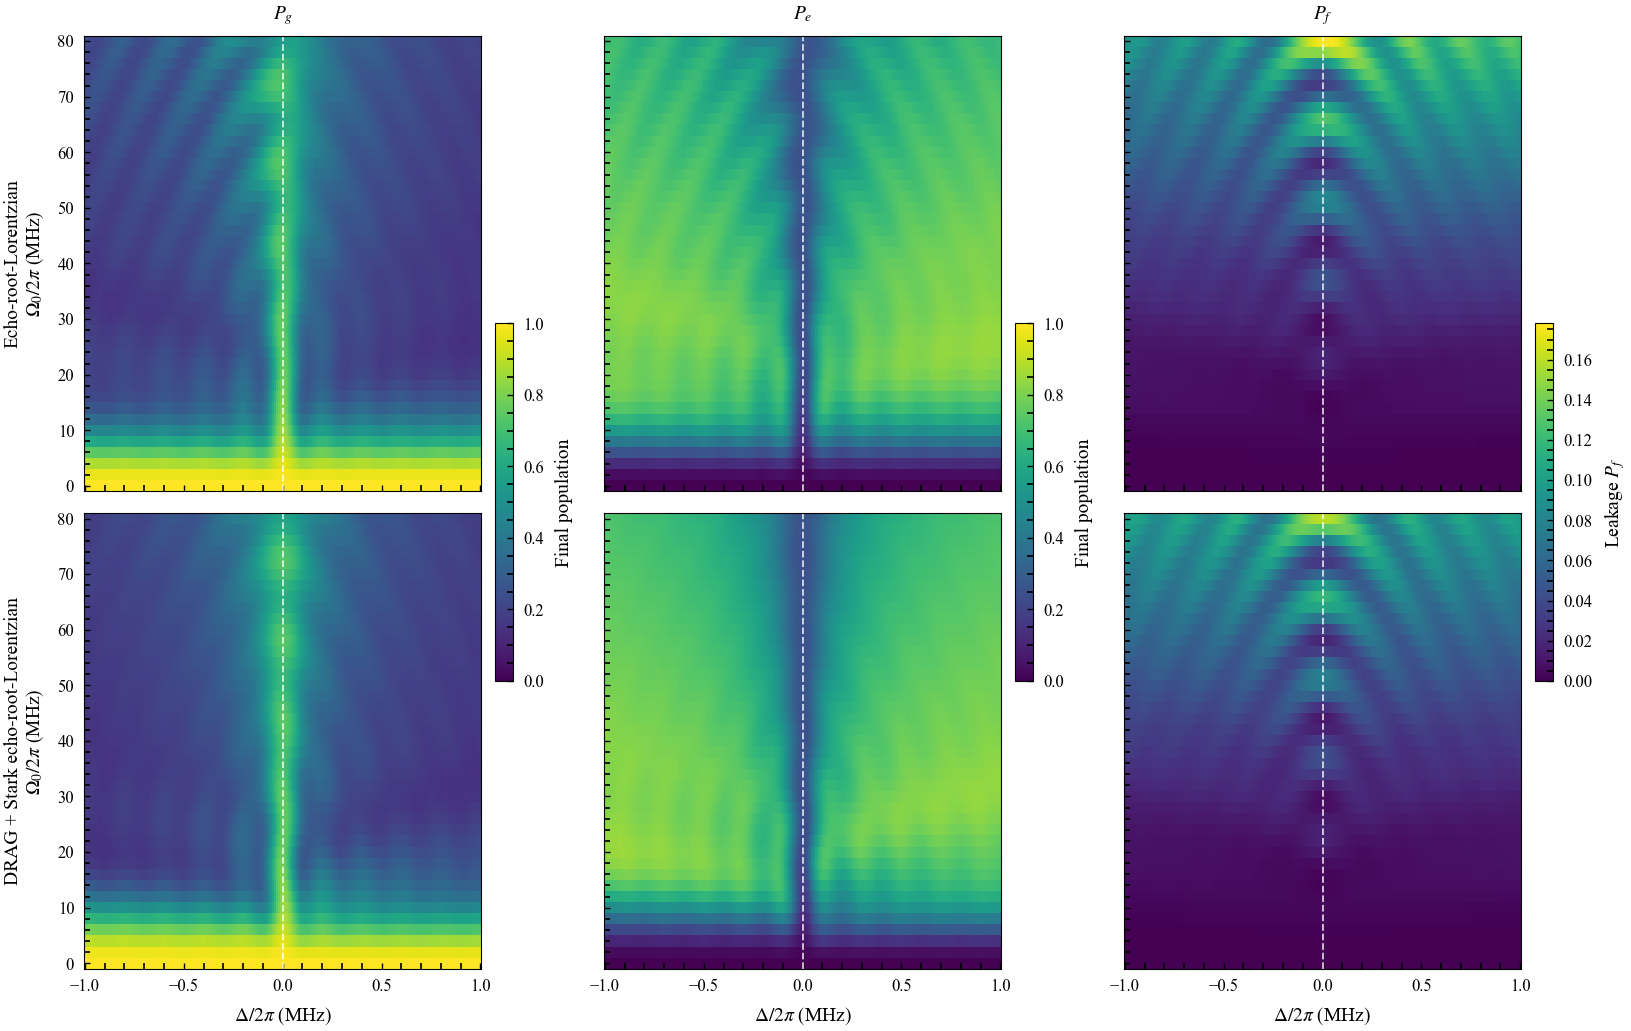

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/13_drag_echo_lorentzian_qutrit_80mhz.pdf
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/13_drag_echo_lorentzian_qutrit_80mhz.png
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/13_drag_echo_lorentzian_qutrit_80mhz.svg


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(8.2, 5.2), sharex=True, sharey=True, constrained_layout=True)
population_names = [('ground', r'$P_g$'), ('excited', r'$P_e$'), ('second_excited', r'$P_f$')]
pf_vmax = max(result.second_excited.max() for result in results.values())
column_images = [None, None, None]
for row, (protocol, result) in enumerate(results.items()):
    for col, (attribute, label) in enumerate(population_names):
        ax = axes[row, col]
        image = ax.pcolormesh(
            DETUNING_MHZ, RABI_MHZ, getattr(result, attribute),
            shading='auto', cmap='viridis', vmin=0,
            vmax=pf_vmax if attribute == 'second_excited' else 1,
            rasterized=True,
        )
        column_images[col] = image
        ax.axvline(0, color='white', lw=0.65, ls='--', alpha=0.8)
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(protocol + '\n' + r'$\Omega_0/2\pi$ (MHz)')
        if row == 1:
            ax.set_xlabel(r'$\Delta/2\pi$ (MHz)')
for col, image in enumerate(column_images):
    fig.colorbar(
        image, ax=axes[:, col], pad=0.012, fraction=0.045,
        label='Final population' if col < 2 else r'Leakage $P_f$',
    )
saved = save_figure(
    fig, '13_drag_echo_lorentzian_qutrit_80mhz',
    variant=FigureVariant.PAPER, formats=('pdf', 'png', 'svg'), dpi=300,
)
plt.show()
print(*saved, sep='\n')

## Leakage change produced by DRAG

The difference map retains its sign: negative values mean that DRAG reduces $P_f$. The line plot reports the maximum leakage over the displayed detuning window at each peak Rabi frequency.

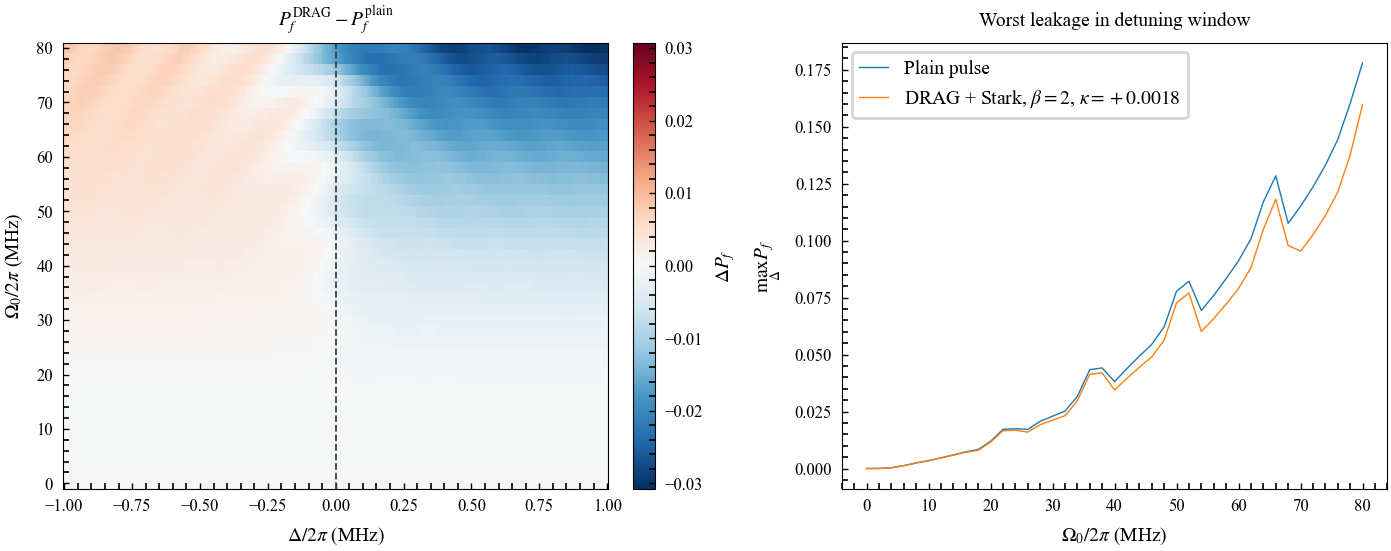

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/14_drag_echo_lorentzian_leakage_change_80mhz.pdf
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/14_drag_echo_lorentzian_leakage_change_80mhz.png
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/14_drag_echo_lorentzian_leakage_change_80mhz.svg


In [7]:
plain = results[PLAIN_NAME]
drag = results[DRAG_NAME]
delta_pf = drag.second_excited - plain.second_excited
limit = np.max(np.abs(delta_pf))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), constrained_layout=True)
difference = axes[0].pcolormesh(
    DETUNING_MHZ, RABI_MHZ, delta_pf, shading='auto', cmap='RdBu_r',
    vmin=-limit, vmax=limit, rasterized=True,
)
axes[0].axvline(0, color='0.25', lw=0.65, ls='--')
axes[0].set_xlabel(r'$\Delta/2\pi$ (MHz)')
axes[0].set_ylabel(r'$\Omega_0/2\pi$ (MHz)')
axes[0].set_title(r'$P_f^{\rm DRAG}-P_f^{\rm plain}$')
fig.colorbar(difference, ax=axes[0], pad=0.02, label=r'$\Delta P_f$')

axes[1].plot(RABI_MHZ, plain.second_excited.max(axis=1), label='Plain pulse')
axes[1].plot(
    RABI_MHZ, drag.second_excited.max(axis=1),
    label=rf'DRAG + Stark, $\beta={DRAG_BETA:g}$, $\kappa={STARK_KAPPA:+.4f}$',
)
axes[1].set_xlabel(r'$\Omega_0/2\pi$ (MHz)')
axes[1].set_ylabel(r'$\max_{\Delta} P_f$')
axes[1].set_title('Worst leakage in detuning window')
axes[1].legend(fontsize=7)
saved = save_figure(
    fig, '14_drag_echo_lorentzian_leakage_change_80mhz',
    variant=FigureVariant.PAPER, formats=('pdf', 'png', 'svg'), dpi=300,
)
plt.show()
print(*saved, sep='\n')

In [8]:
high_mask = RABI_MHZ >= 40
print('Leakage summary')
print('-' * 76)
for protocol, result in results.items():
    print(
        f'{protocol:27s}  full mean/max = '
        f'{result.second_excited.mean():.6f}/{result.second_excited.max():.6f}; '
        f'40--80 MHz mean/max = '
        f'{result.second_excited[high_mask].mean():.6f}/'
        f'{result.second_excited[high_mask].max():.6f}'
    )

Leakage summary
----------------------------------------------------------------------------
Echo-root-Lorentzian         full mean/max = 0.039199/0.178064; 40--80 MHz mean/max = 0.066938/0.178064
DRAG + Stark echo-root-Lorentzian  full mean/max = 0.036139/0.159786; 40--80 MHz mean/max = 0.061352/0.159786
